<a href="https://colab.research.google.com/github/harikautukuru1609/-Advanced-CSS3-Responsive-Architecture/blob/main/dl_project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
np.random.seed(42)

data = {
    "CGPA": np.random.uniform(5.5, 10.0, 500),
    "Aptitude_Score": np.random.randint(30, 101, 500),
    "Technical_Score": np.random.randint(30, 101, 500),
    "Communication_Score": np.random.randint(30, 101, 500),
    "Projects": np.random.randint(0, 6, 500),
    "Internships": np.random.randint(0, 4, 500),
    "Attendance": np.random.randint(60, 101, 500)
}

df = pd.DataFrame(data)

score = (
    df["CGPA"] * 10 +
    df["Aptitude_Score"] * 0.25 +
    df["Technical_Score"] * 0.30 +
    df["Communication_Score"] * 0.15 +
    df["Projects"] * 5 +
    df["Internships"] * 5 +
    df["Attendance"] * 0.10
)

df["Placed"] = (score > 150).astype(int)

df.head()

,CGPA,Aptitude_Score,Technical_Score,Communication_Score,Projects,Internships,Attendance,Placed
0,7.185431,92,56,60,2,0,63,0
1,9.778214,46,86,40,1,2,64,1
2,8.793973,62,60,39,5,3,89,1
3,8.193963,58,35,96,4,3,83,1
4,6.202084,42,69,43,4,1,62,0


In [5]:
X = df.drop("Placed", axis=1)
y = df["Placed"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_lstm = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_lstm,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (400, 7, 1)
Testing: (100, 7, 1)


In [6]:
model = Sequential([
    LSTM(64, input_shape=(7, 1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7531 - loss: 0.6291 - val_accuracy: 0.8125 - val_loss: 0.5355
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8687 - loss: 0.4242 - val_accuracy: 0.8625 - val_loss: 0.3555
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8625 - loss: 0.3181 - val_accuracy: 0.8500 - val_loss: 0.3370
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8813 - loss: 0.3037 - val_accuracy: 0.8625 - val_loss: 0.3281
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8844 - loss: 0.2997 - val_accuracy: 0.8625 - val_loss: 0.3223
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8813 - loss: 0.2956 - val_accuracy: 0.8625 - val_loss: 0.3284
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.2934 - val_accuracy: 0.8625 - val_loss: 0.3234
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8813 - loss: 0.2874 - val_accuracy: 0.8625 - val_loss

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9800 - loss: 0.0774 
Test Accuracy: 98.0 %


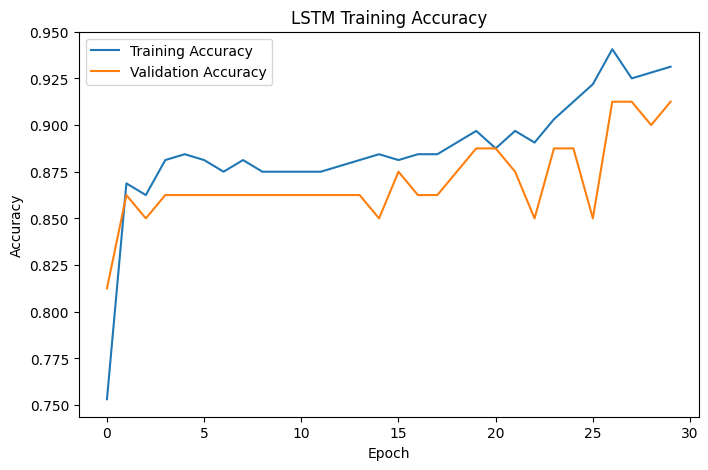

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

In [10]:
cgpa = float(input("Enter CGPA: "))
aptitude = float(input("Enter Aptitude Score: "))
technical = float(input("Enter Technical Score: "))
communication = float(input("Enter Communication Score: "))
projects = int(input("Enter Number of Projects: "))
internships = int(input("Enter Number of Internships: "))
attendance = float(input("Enter Attendance Percentage: "))

student = np.array([[
    cgpa,
    aptitude,
    technical,
    communication,
    projects,
    internships,
    attendance
]])

student_scaled = scaler.transform(student)

student_lstm = student_scaled.reshape(1, 7, 1)

prediction = model.predict(student_lstm, verbose=0)

probability = prediction[0][0] * 100

print("\nPlacement Probability:", round(probability, 2), "%")

if probability >= 50:
    print("Prediction: PLACED")
else:
    print("Prediction: NOT PLACED")

Enter CGPA: 8.5
Enter Aptitude Score: 75
Enter Technical Score: 80
Enter Communication Score: 70
Enter Number of Projects: 3
Enter Number of Internships: 1
Enter Attendance Percentage: 85


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Placement Probability: 99.93 %
Prediction: PLACED
